In [18]:
import joblib
import os
import cv2
import numpy as np
import pandas as pd
import torch
model = joblib.load('classifier.pkl')

In [19]:
class Dataset:
    def __init__(self,image_path):
        self.image_path=image_path
    def compute_otsuscore(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        resized_img = cv2.resize(image, (256, 256))
        hist=cv2.calcHist([resized_img], [0], None, [256], [0, 256]).ravel()
        hist_norm=hist/hist.sum()
        cum_sum=np.cumsum(hist_norm)
        cum_mean = np.cumsum(np.arange(256) * hist_norm)
        global_mean=cum_mean[-1]
        sigma_b_mean = ((global_mean * cum_sum - cum_mean) ** 2) / (cum_sum * (1 - cum_sum) + 1e-7)
        return sigma_b_mean[np.argmax(sigma_b_mean)]
    def compute_fft(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        ft=np.fft.fft2(image)
        ft_shift=np.fft.fftshift(ft)
        magnitude_spectrum = 20 * np.log(np.abs(ft_shift) + 1)
        return np.mean(magnitude_spectrum)  
    def laplace_variance(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        laplace_img=cv2.Laplacian(image,cv2.CV_64F)
        return laplace_img.var()
    def gradient_energy(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        gx,gy=np.gradient(image)
        energy=gx**2 + gy**2
        return np.mean(energy) 
    def michelson_contrast(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        image = image.astype(np.float64)
        min_val=np.min(image)
        max_val=np.max(image)
        y=max_val+min_val
        if y==0 or np.isinf(y) or np.isnan(y):
            return 0.0
        contrast=(max_val- min_val) / (max_val + min_val)
        return contrast
    def canny_edge_count(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        edges=cv2.Canny(image, threshold1=30, threshold2=100)
        return np.count_nonzero(edges)

In [25]:
image_path=r"D:\COMPUTER_VISION\anomaly_detection_test_data\anomaly_detection_test_data\bad\03_08_2024_16_59_07.698036_classifier_input.png"
d = Dataset(image_path)

results=[]
img_dict = {
            'otsu_score': d.compute_otsuscore(),
            'fft': d.compute_fft(),
            'variance': d.laplace_variance(),
            'gradient_energy': d.gradient_energy(),
            'michaelson_contrast': d.michelson_contrast(),
            'canny_edge': d.canny_edge_count()
        }

results.append(img_dict)

X_test=pd.DataFrame(results)

Bad image → Running segmentation...


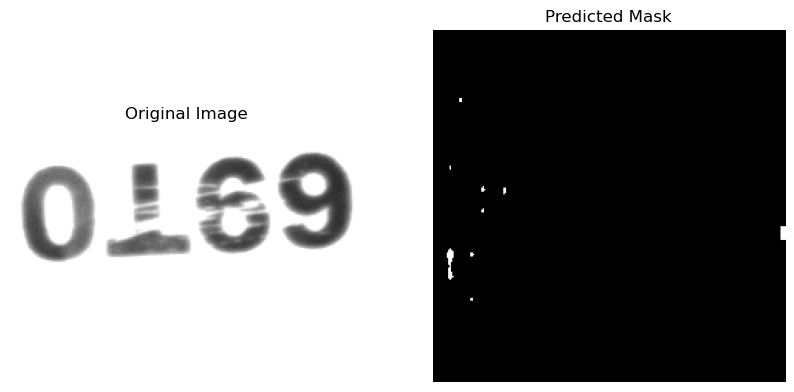

In [26]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.serialization import add_safe_globals
from torchvision.models.segmentation import DeepLabV3


add_safe_globals([DeepLabV3])


result = model.predict(X_test)
pred_class = int(result[0])

if pred_class == 0:
    print("Bad image → Running segmentation...")


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    seg_model = torch.load(
        "deeplabv3_full.pth",
        map_location=device,
        weights_only=False  
    )

    seg_model.to(device)
    seg_model.eval()


    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = seg_model(input_tensor)["out"]  
        output = torch.sigmoid(output)

        if output.shape[1] == 1:
 
            pred_mask = (output[0, 0] > 0.5).cpu().numpy()
        else:

            pred_mask = torch.argmax(output, dim=1)[0].cpu().numpy()
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

else:
    print("Good image → No localization needed.")
